<a href="https://colab.research.google.com/github/Tanury/Wildfire-Detection-SSL/blob/main/FireNoFire_SSL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub pytorch-lightning torchmetrics

import kagglehub
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from torchmetrics.functional import accuracy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 50.7 MB/s eta 0:00:00


In [2]:
path = kagglehub.dataset_download("datascientist97/forest-fire-dataset-binary-classification")
print("Path to dataset files:", path)

train_dir = os.path.join(path, "train")
val_dir   = os.path.join(path, "val")
test_dir  = os.path.join(path, "test")

100%|██████████| 742M/742M [00:10<00:00, 75.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/datascientist97/forest-fire-dataset-binary-classification/versions/3


In [3]:
import os

print("Dataset root:", path)
print("\nFiles and folders in dataset root:")
print(os.listdir(path))


Dataset root: /root/.cache/kagglehub/datasets/datascientist97/forest-fire-dataset-binary-classification/versions/3

Files and folders in dataset root:
['Forest-Fire-Cleaned', 'Forest-Fire-Cleaned-dataV2']


In [4]:
import os
from PIL import Image, UnidentifiedImageError
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = os.path.join(path, "Forest-Fire-Cleaned/Forest-Fire-Cleaned/train")
val_dir   = os.path.join(path, "Forest-Fire-Cleaned/Forest-Fire-Cleaned/val")
test_dir  = os.path.join(path, "Forest-Fire-Cleaned/Forest-Fire-Cleaned/test")

# Function to remove corrupted images
def remove_corrupted_images(root_dir):
    print("Checking for corrupted images...")
    removed_count = 0
    for subdir, _, files in os.walk(root_dir):
        for file in files:
            file_path = os.path.join(subdir, file)
            try:
                img = Image.open(file_path)
                img.verify()  # verify image integrity
            except (UnidentifiedImageError, IOError, OSError):
                print(f"⚠️ Removing corrupted image: {file_path}")
                os.remove(file_path)
                removed_count += 1
    print(f"Done. Removed {removed_count} corrupted images.\n")

# Remove corrupted images from all splits
remove_corrupted_images(train_dir)
remove_corrupted_images(val_dir)
remove_corrupted_images(test_dir)

# Safe PIL loader (backup, just in case)
def pil_loader(path):
    try:
        with open(path, "rb") as f:
            img = Image.open(f)
            return img.convert("RGB")
    except (UnidentifiedImageError, IOError):
        print(f"⚠️ Skipping corrupted image: {path}")
        return Image.new("RGB", (224, 224), (0, 0, 0))

print("Train samples:", len(os.listdir(os.path.join(train_dir, 'fire'))) + len(os.listdir(os.path.join(train_dir, 'nofire'))))
print("Val samples:", len(os.listdir(os.path.join(val_dir, 'fire'))) + len(os.listdir(os.path.join(val_dir, 'nofire'))))
print("Test samples:", len(os.listdir(os.path.join(test_dir, 'fire'))) + len(os.listdir(os.path.join(test_dir, 'nofire'))))


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


Checking for corrupted images...
Done. Removed 0 corrupted images.

Checking for corrupted images...
⚠️ Removing corrupted image: /root/.cache/kagglehub/datasets/datascientist97/forest-fire-dataset-binary-classification/versions/3/Forest-Fire-Cleaned/Forest-Fire-Cleaned/val/fire/F_725.jpg
⚠️ Removing corrupted image: /root/.cache/kagglehub/datasets/datascientist97/forest-fire-dataset-binary-classification/versions/3/Forest-Fire-Cleaned/Forest-Fire-Cleaned/val/fire/F_653.jpg
⚠️ Removing corrupted image: /root/.cache/kagglehub/datasets/datascientist97/forest-fire-dataset-binary-classification/versions/3/Forest-Fire-Cleaned/Forest-Fire-Cleaned/val/fire/F_747.jpg
⚠️ Removing corrupted image: /root/.cache/kagglehub/datasets/datascientist97/forest-fire-dataset-binary-classification/versions/3/Forest-Fire-Cleaned/Forest-Fire-Cleaned/val/fire/F_876.jpg
⚠️ Removing corrupted image: /root/.cache/kagglehub/datasets/datascientist97/forest-fire-dataset-binary-classification/versions/3/Forest-Fire-C

In [5]:
# ===============================
# 4. Self-Supervised Pretraining (SimCLR)
# ===============================
class SimCLRTransform:
    """Two random augmentations of same image"""
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter()], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.ToTensor(),
        ])
    def __call__(self, x):
        return self.transform(x), self.transform(x)

# Self-supervised dataset (using only train_dir)
ssl_dataset = datasets.ImageFolder(train_dir, transform=SimCLRTransform(), loader=pil_loader)
ssl_loader  = DataLoader(ssl_dataset, batch_size=64, shuffle=True, num_workers=2)

class SimCLR(pl.LightningModule):
    def __init__(self, backbone, in_dim, projection_dim=128, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['backbone'])  # don't serialize backbone twice
        self.backbone = backbone
        self.projector = nn.Sequential(
            nn.Linear(in_dim, in_dim), nn.ReLU(),
            nn.Linear(in_dim, projection_dim)
        )
        self.lr = lr

    def info_nce_loss(self, z1, z2, temperature=0.5):
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        reps = torch.cat([z1, z2], dim=0)
        sim = torch.matmul(reps, reps.T) / temperature
        labels = torch.arange(len(reps)//2, device=self.device)
        labels = torch.cat([labels, labels], dim=0)
        mask = torch.eye(len(reps), device=self.device).bool()
        sim = sim.masked_fill(mask, -9e15)
        return F.cross_entropy(sim, labels)

    def training_step(self, batch, batch_idx):
        (x1, x2), _ = batch
        z1 = self.projector(self.backbone(x1))
        z2 = self.projector(self.backbone(x2))
        loss = self.info_nce_loss(z1, z2)
        self.log("ssl_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# Backbone setup
backbone = models.resnet18(pretrained=False)
feature_dim = backbone.fc.in_features   # save feature dimension
backbone.fc = nn.Identity()             # remove classification head

ssl_model = SimCLR(backbone, in_dim=feature_dim)

# Train self-supervised model
trainer = pl.Trainer(max_epochs=5, accelerator="auto")
trainer.fit(ssl_model, ssl_loader)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPU

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [6]:
# ===============================
# 5. Fine-tune with labeled dataset
# ===============================
class Classifier(pl.LightningModule):
    def __init__(self, backbone, feature_dim, num_classes=2, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['backbone'])  # ignore backbone in checkpoint
        self.backbone = backbone
        self.classifier = nn.Linear(feature_dim, num_classes)
        self.lr = lr

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = accuracy(logits.softmax(dim=-1), y, task="multiclass", num_classes=2)
        self.log("train_loss", loss)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = accuracy(logits.softmax(dim=-1), y, task="multiclass", num_classes=2)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        acc = accuracy(logits.softmax(dim=-1), y, task="multiclass", num_classes=2)
        self.log("test_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# Initialize classifier with pretrained backbone
classifier = Classifier(ssl_model.backbone, feature_dim=feature_dim, num_classes=2)

# Fine-tune
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    callbacks=[EarlyStopping(monitor="val_loss", patience=3)]
)
trainer.fit(classifier, train_loader, val_loader)

# Final test evaluation
trainer.test(classifier, test_loader)


INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name       | Type   | Params | Mode 
----------------------------------------------
0 | backbone   | ResNet | 11.2 M | train
1 | classifier | Linear | 1.0 K  | train
----------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)
69        Modules in train mo

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.954875111579895     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.954875111579895}]

In [7]:
trainer.test(classifier, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.954875111579895     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.954875111579895}]

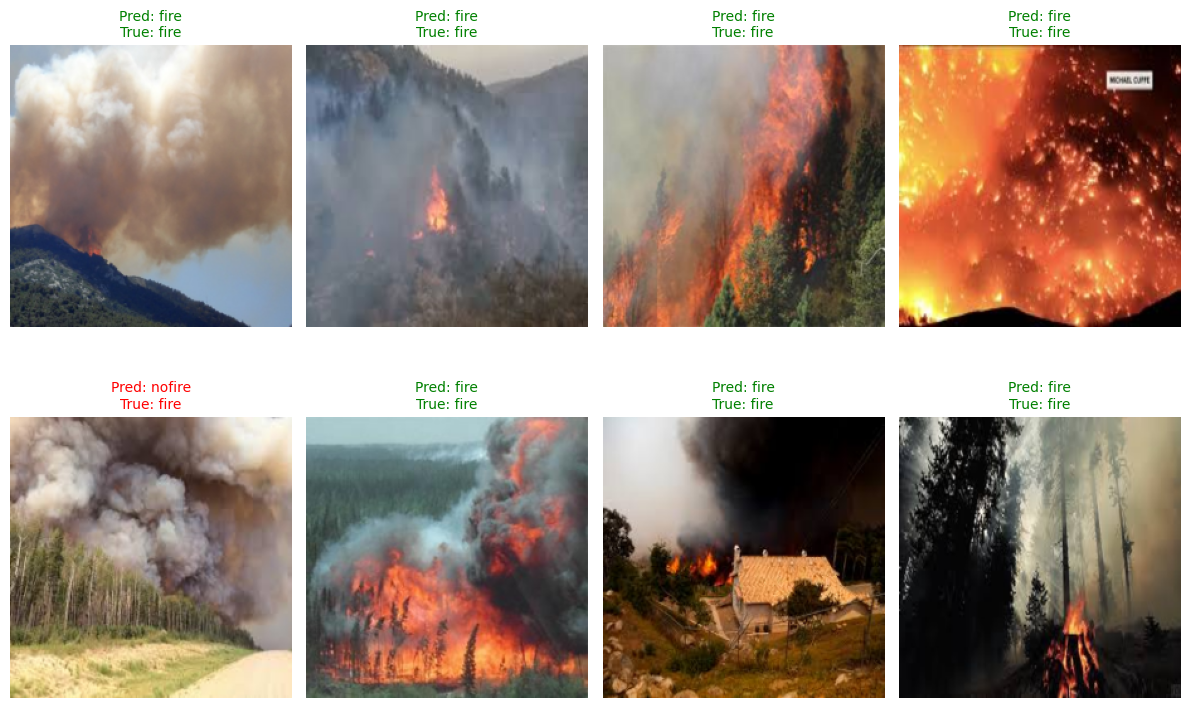

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Class names from dataset
class_names = train_dataset.classes  # ['fire', 'nofire']

# Function to unnormalize and show image
def imshow(inp, title=None, color="black"):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title, color=color, fontsize=10)
    plt.axis("off")

# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classifier.to(device)
images = images.to(device)
labels = labels.to(device)

# Get predictions
classifier.eval()
with torch.no_grad():
    outputs = classifier(images)
    _, preds = torch.max(outputs, 1)

# Plot a few predictions
plt.figure(figsize=(12, 8))
for idx in range(8):  # show first 8 images
    ax = plt.subplot(2, 4, idx + 1)
    correct = preds[idx] == labels[idx]
    color = "green" if correct else "red"
    title = f"Pred: {class_names[preds[idx]]}\nTrue: {class_names[labels[idx]]}"
    imshow(images[idx].cpu(), title=title, color=color)
plt.tight_layout()
plt.show()


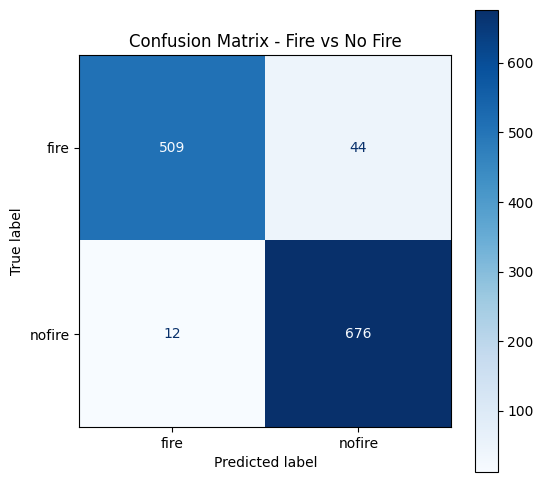

In [9]:
#confusion matrix
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Put model in eval mode
classifier.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0,1])  # 0: fire, 1: nofire
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format="d")
plt.title("Confusion Matrix - Fire vs No Fire")
plt.show()


In [10]:
# 9. Classification Report

from sklearn.metrics import classification_report

# Generate precision, recall, F1 per class
report = classification_report(all_labels, all_preds, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        fire       0.98      0.92      0.95       553
      nofire       0.94      0.98      0.96       688

    accuracy                           0.95      1241
   macro avg       0.96      0.95      0.95      1241
weighted avg       0.96      0.95      0.95      1241



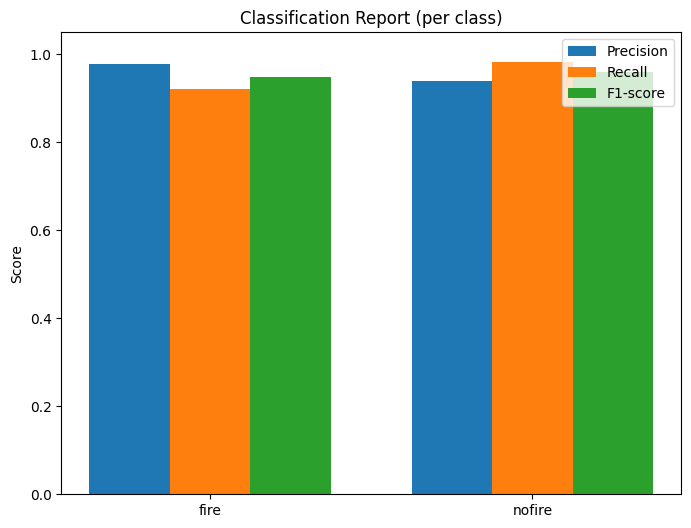

In [11]:
#classification report - (the visual version)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Get precision, recall, f1 for each class
precisions, recalls, f1s, _ = precision_recall_fscore_support(all_labels, all_preds, labels=[0,1])

# X axis positions
x = np.arange(len(class_names))  # [0,1] for 'fire', 'nofire'
width = 0.25

plt.figure(figsize=(8,6))
plt.bar(x - width, precisions, width, label='Precision')
plt.bar(x, recalls, width, label='Recall')
plt.bar(x + width, f1s, width, label='F1-score')

# Formatting
plt.xticks(x, class_names)
plt.ylim(0,1.05)
plt.ylabel("Score")
plt.title("Classification Report (per class)")
plt.legend()
plt.show()


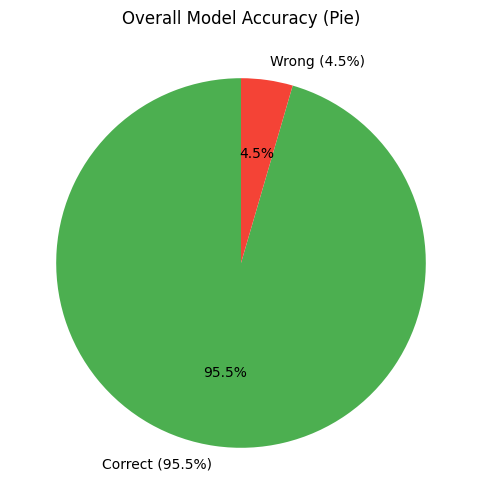

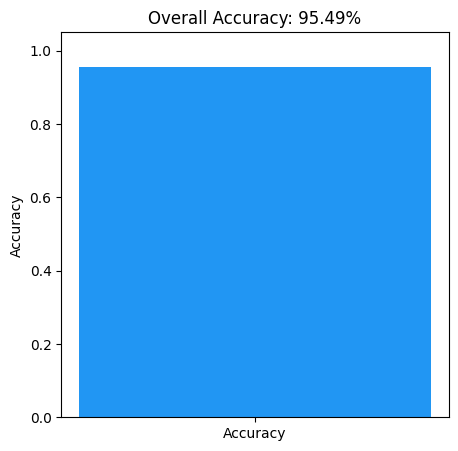

In [12]:
#overall accuracy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate overall accuracy
accuracy = accuracy_score(all_labels, all_preds)

# --- Pie Chart ---
plt.figure(figsize=(6,6))
plt.pie([accuracy, 1-accuracy],
        labels=[f"Correct ({accuracy*100:.1f}%)", f"Wrong ({(1-accuracy)*100:.1f}%)"],
        colors=["#4CAF50", "#F44336"],
        autopct="%1.1f%%",
        startangle=90)
plt.title("Overall Model Accuracy (Pie)")
plt.show()

# --- Single Bar Chart ---
plt.figure(figsize=(5,5))
plt.bar(["Accuracy"], [accuracy], color="#2196F3")
plt.ylim(0,1.05)
plt.ylabel("Accuracy")
plt.title(f"Overall Accuracy: {accuracy*100:.2f}%")
plt.show()


In [13]:
"""
🔑 How the Dataset is Utilised

The dataset (fire, nofire) is labeled, but in Step 4 (SSL Pretraining) we ignore the labels.
Instead, we only use raw images and apply random augmentations (crops, flips, color jitter, grayscale).
Each augmented view of the same image is treated as a positive pair, while views from other images are treated as negative pairs.
This allows the model to learn useful visual features (edges, textures, patterns of smoke, fire color, forest background) without using labels.

🔑 Key Aspects of SSL Used Here

Contrastive Learning (SimCLR style)
The InfoNCE loss encourages the model to bring embeddings of the same image (different augmentations) closer, and push apart embeddings of different images.
This forces the backbone (ResNet18 here) to learn general, meaningful representations of images.

Projection Head
The SSL stage has a small MLP (“projector”) after the backbone.
This is used only during pretraining to map features into a space where contrastive loss works better.

Backbone Feature Learning
The pretrained ResNet18 backbone learns to detect patterns in the dataset (fire textures, smoke, forest features) in an unsupervised way.

Fine-tuning with Labels
In Step 5, we remove the projector and add a classifier head (Linear(feature_dim, 2)).
Now, we fine-tune on the small labeled dataset (fire, nofire) to perform supervised classification.
Because the backbone already learned good features, fine-tuning converges faster and often performs better, especially if labels are limited.
"""


'\n🔑 How the Dataset is Utilised\n\nThe dataset (fire, nofire) is labeled, but in Step 4 (SSL Pretraining) we ignore the labels.\nInstead, we only use raw images and apply random augmentations (crops, flips, color jitter, grayscale).\nEach augmented view of the same image is treated as a positive pair, while views from other images are treated as negative pairs.\nThis allows the model to learn useful visual features (edges, textures, patterns of smoke, fire color, forest background) without using labels.\n\n🔑 Key Aspects of SSL Used Here\n\nContrastive Learning (SimCLR style)\nThe InfoNCE loss encourages the model to bring embeddings of the same image (different augmentations) closer, and push apart embeddings of different images.\nThis forces the backbone (ResNet18 here) to learn general, meaningful representations of images.\n\nProjection Head\nThe SSL stage has a small MLP (“projector”) after the backbone.\nThis is used only during pretraining to map features into a space where cont